In [17]:
# IMPORTAR LIBRERÍAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [19]:
# CARGAR DATASET

df = pd.read_csv("heart.csv")

# Mostrar primeras filas
print(df.head())


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [21]:
# EXPLORACIÓN DE DATO

print(df.info())

print(df.describe())

# Verificar valores nulos
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.0

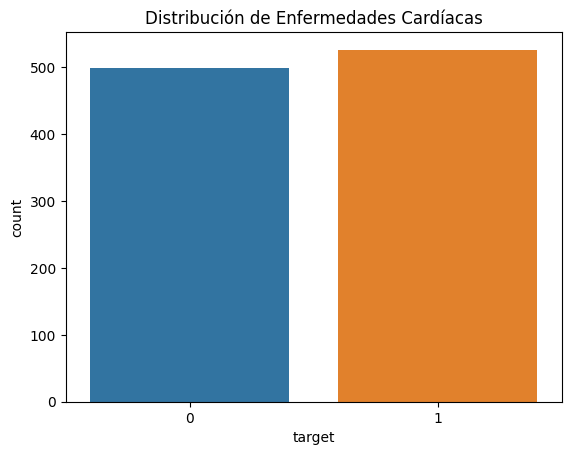

In [23]:
# GRÁFICO VARIABLES OBJETIVO
sns.countplot(x='target', data=df)

plt.title("Distribución de Enfermedades Cardíacas")

plt.show()


In [25]:
# VARIABLES PREDICTORAS Y OBJETIVO

X = df.drop('target', axis=1)

y = df['target']


In [27]:
# DIVISIÓN DE DATOS

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# ESCALADO DE DATOS

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Accuracy Árbol de Decisión: 0.9707792207792207
[[159   0]
 [  9 140]]


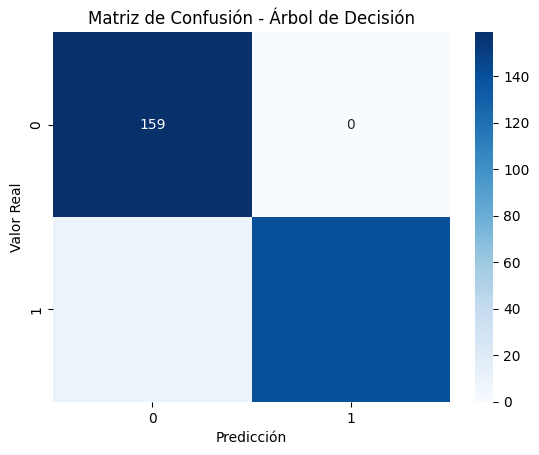

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       159
           1       1.00      0.94      0.97       149

    accuracy                           0.97       308
   macro avg       0.97      0.97      0.97       308
weighted avg       0.97      0.97      0.97       308



In [40]:
# MODELO 1: ÁRBOL DE DECISIÓN

arbol = DecisionTreeClassifier(random_state=42)

arbol.fit(X_train, y_train)

y_pred_arbol = arbol.predict(X_test)

# Accuracy
acc_arbol = accuracy_score(y_test, y_pred_arbol)

print("Accuracy Árbol de Decisión:", acc_arbol)

# Matriz de confusión
print(confusion_matrix(y_test, y_pred_arbol))
matriz_arbol = confusion_matrix(y_test, y_pred_arbol)

sns.heatmap(
    matriz_arbol,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusión - Árbol de Decisión")

plt.xlabel("Predicción")

plt.ylabel("Valor Real")

plt.show()

# Reporte de clasificación
print(classification_report(y_test, y_pred_arbol))

Accuracy K-NN: 0.8409090909090909
[[130  29]
 [ 20 129]]


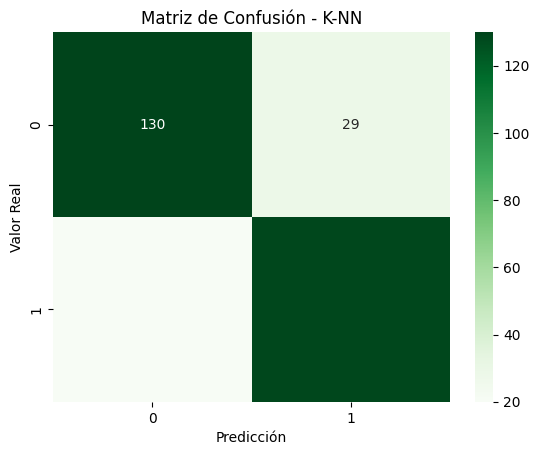

              precision    recall  f1-score   support

           0       0.87      0.82      0.84       159
           1       0.82      0.87      0.84       149

    accuracy                           0.84       308
   macro avg       0.84      0.84      0.84       308
weighted avg       0.84      0.84      0.84       308



In [38]:
# MODELO 2: K-NN

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

# Accuracy
acc_knn = accuracy_score(y_test, y_pred_knn)

print("Accuracy K-NN:", acc_knn)

# Matriz de confusión
print(confusion_matrix(y_test, y_pred_knn))
matriz_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(
    matriz_knn,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Matriz de Confusión - K-NN")

plt.xlabel("Predicción")

plt.ylabel("Valor Real")

plt.show()

# Reporte de clasificación
print(classification_report(y_test, y_pred_knn))

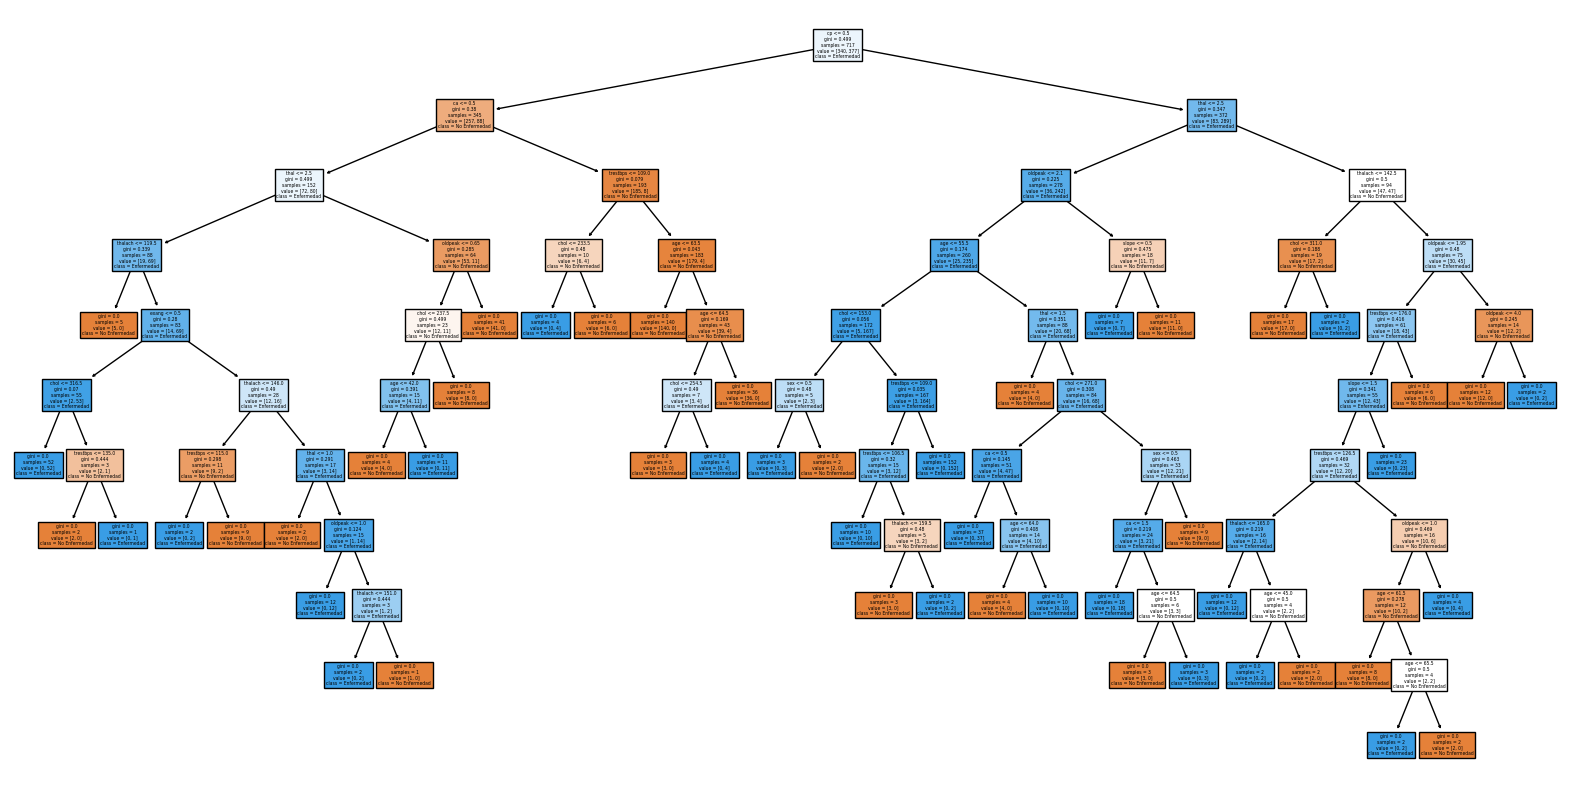

In [33]:
#VISAUALIZAR ARBOL DE DECISION

plt.figure(figsize=(20,10))

tree.plot_tree(
    arbol,
    filled=True,
    feature_names=X.columns,
    class_names=['No Enfermedad', 'Enfermedad']
)

plt.show()

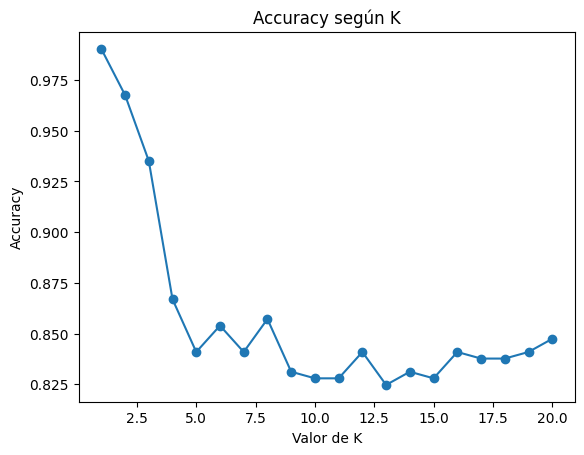

In [36]:
# CALCULO DE VALOR K EN MODELO K-NN
valores_k = []

for k in range(1, 21):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    pred = knn.predict(X_test_scaled)

    valores_k.append(accuracy_score(y_test, pred))

plt.plot(range(1, 21), valores_k, marker='o')

plt.xlabel("Valor de K")

plt.ylabel("Accuracy")

plt.title("Accuracy según K")

plt.show()